# 01 — EDA · P8-Data-Analyst
**Bootcamp IA P4 · Factoría F5 Madrid**  
**Entrada:** `data/processed/airbnb_homogenizado.csv`  
**Requisito previo:** ejecutar `00_homogenizacion.ipynb`

---

## Objetivo

Extraer conclusiones accionables sobre el mercado AirBnB en 6 ciudades a partir del dataset homogenizado.  
Cada sección incluye el razonamiento de por qué se aplica cada técnica y la interpretación de los resultados obtenidos.

## Estructura
1. Carga y visión general
2. Análisis univariante — distribuciones individuales
3. Análisis bivariante — relaciones entre variables
4. Análisis multivariante — correlaciones y patrones globales
5. Patrones geográficos
6. Conclusiones y hallazgos

> **[SDD — Spec-Driven Development]**  
> Este notebook carga datos ya limpios. No realiza transformaciones — solo análisis y visualización.  
> Cada celda de código va precedida de una celda Markdown que explica qué se analiza y por qué.

## 0. Imports y carga

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
PALETA = sns.color_palette('tab10', 6)

print('✅ Librerías cargadas')

✅ Librerías cargadas


In [2]:
# SDD: Carga del dataset homogenizado — entrada de este notebook
RUTA = 'data/processed/airbnb_homogenizado.csv'

df = pd.read_csv(RUTA, parse_dates=['last_review'], low_memory=False)

print(f'Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Ciudades: {sorted(df["city"].unique())}')
print(f'Columnas: {list(df.columns)}')
df.head(3)

Dataset: 219,981 filas × 16 columnas
Ciudades: ['London', 'Madrid', 'Milan', 'New York', 'Sydney', 'Tokyo']
Columnas: ['id', 'name', 'host_id', 'host_name', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'price_eur', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'city', 'moneda_origen']


,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,price_eur,minimum_nights,number_of_reviews,last_review,reviews_per_month,city,moneda_origen
0,2539,Clean & quiet apt home by the park,2787,John,Kensington,40.64749,-73.97237,Private room,149,137.08,1,9,2018-10-19,0.21,New York,USD
1,2595,Skylit Midtown Castle,2845,Jennifer,Midtown,40.75362,-73.98377,Entire home/apt,225,207.00,1,45,2019-05-21,0.38,New York,USD
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Harlem,40.80902,-73.94190,Private room,150,138.00,3,0,NaT,0.00,New York,USD


---
## 1. Visión general del dataset

> **[SDD]** Antes de cualquier análisis, entender la estructura básica: ¿cuántos registros por ciudad? ¿qué tipos de alojamiento existen? ¿hay nulos residuales?  

**Razonamiento:** Una visión general permite detectar asimetrías en el tamaño de los datasets (una ciudad con 10× más registros que otra dominaría cualquier estadístico global) y confirmar que la homogenización fue exitosa.

In [3]:
# SDD: Estadística descriptiva base
print('=== FORMA DEL DATASET ===')
print(df.describe(include='all').T[['count','mean','std','min','max']].to_string())
print()
print('=== NULOS RESIDUALES ===')
nulos = df.isnull().sum()
print(nulos[nulos > 0].to_string() if nulos.any() else '✅ Sin nulos en columnas clave')

=== FORMA DEL DATASET ===
                      count                        mean              std                  min                  max
id                 219981.0             22407888.468772  11755508.469248               2539.0           50955051.0
name                 219981                         NaN              NaN                  NaN                  NaN
host_id            219981.0             84940054.345057  88561284.019058               1944.0          411720762.0
host_name            219981                         NaN              NaN                  NaN                  NaN
neighbourhood        219981                         NaN              NaN                  NaN                  NaN
latitude           219981.0                   32.573472        30.144701           -34.135212             51.68169
longitude          219981.0                   16.426981        76.029481            -74.24442           151.339811
room_type            219981                         Na

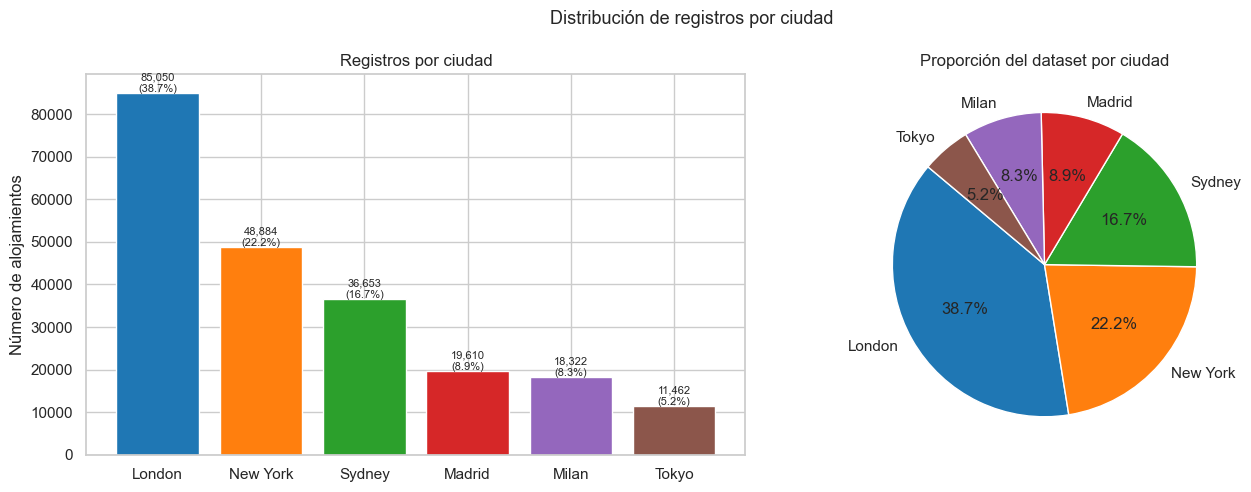

In [4]:
# Distribución de registros por ciudad
conteo = df['city'].value_counts()
pct    = (conteo / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(conteo.index, conteo.values, color=PALETA)
axes[0].set_title('Registros por ciudad')
axes[0].set_ylabel('Número de alojamientos')
for i, (v, p) in enumerate(zip(conteo.values, pct.values)):
    axes[0].text(i, v + 200, f'{v:,}\n({p}%)', ha='center', fontsize=8)

axes[1].pie(conteo.values, labels=conteo.index, autopct='%1.1f%%',
            colors=PALETA, startangle=140)
axes[1].set_title('Proporción del dataset por ciudad')

plt.suptitle('Distribución de registros por ciudad', fontsize=13)
plt.tight_layout()
plt.show()

### 📊 Interpretación — Distribución por ciudad

**Qué observar:** ¿Hay ciudades con un peso desproporcionado en el dataset?  
- Si una ciudad representa >40% del total, los estadísticos globales estarán sesgados hacia sus patrones.  
- En ese caso, los análisis comparativos deben hacerse siempre **segmentados por ciudad**, no sobre el total.  
- La ciudad más representada en datasets de Inside AirBnB suele ser Londres o Nueva York — ambas con mercados de alquiler vacacional muy activos y bien documentados.

---
## 2. Análisis univariante

### 2.1 Variable objetivo: `room_type`

> **[SDD]** Verificar el balance de la variable categórica central. Un desequilibrio severo (>80% en una categoría) limitaría la capacidad discriminante de cualquier modelo.

**Razonamiento:** `room_type` es la variable que mejor define el tipo de oferta en AirBnB y es el predictor más intuitivo del precio. Entender su distribución global y por ciudad es el primer paso del análisis.

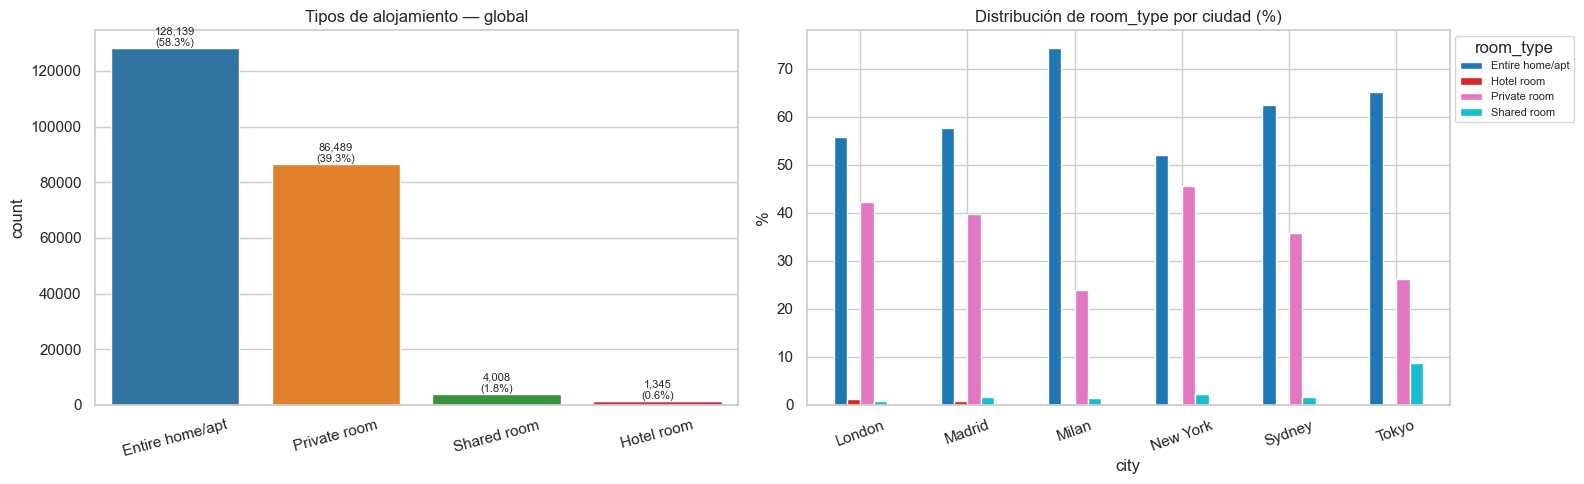


Distribución global:
room_type
Entire home/apt    58.3
Private room       39.3
Shared room         1.8
Hotel room          0.6


In [5]:
# SDD: Frecuencias de room_type — Rúbrica: Análisis exploratorio detallado
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Global
orden = df['room_type'].value_counts().index
sns.countplot(data=df, x='room_type', order=orden, ax=axes[0], palette='tab10')
axes[0].set_title('Tipos de alojamiento — global')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)
total = len(df)
for p in axes[0].patches:
    pct = p.get_height() / total * 100
    axes[0].annotate(f'{p.get_height():,.0f}\n({pct:.1f}%)',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=8)

# Por ciudad
ct = df.groupby(['city','room_type']).size().unstack(fill_value=0)
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', ax=axes[1], colormap='tab10')
axes[1].set_title('Distribución de room_type por ciudad (%)')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(title='room_type', bbox_to_anchor=(1,1), fontsize=8)

plt.tight_layout()
plt.show()

print('\nDistribución global:')
print(df['room_type'].value_counts(normalize=True).mul(100).round(1).to_string())

### 📊 Interpretación — room_type

**Qué esperar:** En la mayoría de mercados AirBnB, `Entire home/apt` domina (~60-70%), seguido de `Private room` (~30%). `Shared room` y `Hotel room` son minoritarios (<5%).  
**Implicación para el análisis:** Las comparativas de precio entre ciudades deben hacerse **dentro del mismo room_type** para ser justas. Un precio medio que mezcle pisos enteros y habitaciones privadas no es comparable entre ciudades con distinta composición.

### 2.2 Precio en EUR — distribución y outliers

> **[SDD]** Analizar la distribución de `price_eur` con histograma y KDE. Detectar outliers con IQR. Documentar la decisión de tratamiento.

**Razonamiento:** Los precios de AirBnB típicamente siguen una distribución log-normal: la mayoría de alojamientos tienen precios moderados, pero hay una cola derecha larga de alojamientos de lujo. Visualizar esto es fundamental para decidir si hay que aplicar transformación logarítmica antes del modelado.

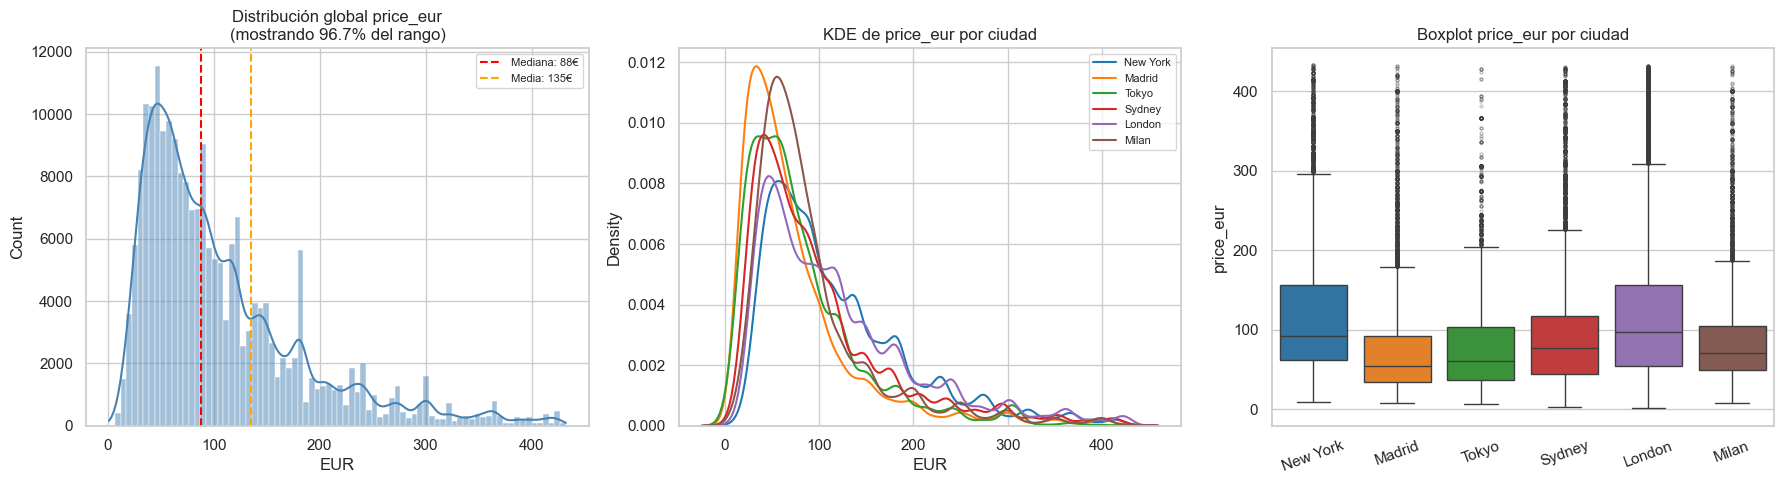


Estadísticos de precio (EUR):
            count   mean    std  min   25%    50%    75%      max
city                                                             
London    85050.0  148.1  267.1  1.2  56.9  101.6  169.4  14937.4
Madrid    19610.0  129.3  484.2  8.0  35.0   58.0  100.0   9999.0
Milan     18322.0  115.1  290.8  8.0  50.0   73.5  110.0  11999.0
New York  48884.0  140.5  221.0  9.2  63.5   97.5  161.0   9200.0
Sydney    36653.0  122.6  191.1  3.5  47.2   80.2  132.2   8849.4
Tokyo     11462.0   91.4  203.0  6.6  36.8   61.0  105.0   6100.3


In [6]:
# SDD: Distribución de precios — Rúbrica: Visualización con seaborn/matplotlib

# Calcular IQR para determinar límite de visualización razonable
Q1  = df['price_eur'].quantile(0.25)
Q3  = df['price_eur'].quantile(0.75)
IQR = Q3 - Q1
LIM_VIZ = Q3 + 3 * IQR  # k=3 para no cortar demasiado

df_viz = df[df['price_eur'] <= LIM_VIZ]
pct_mostrado = len(df_viz) / len(df) * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma global
sns.histplot(df_viz['price_eur'], bins=80, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title(f'Distribución global price_eur\n(mostrando {pct_mostrado:.1f}% del rango)')
axes[0].set_xlabel('EUR')
axes[0].axvline(df['price_eur'].median(), color='red', ls='--', label=f'Mediana: {df["price_eur"].median():.0f}€')
axes[0].axvline(df['price_eur'].mean(),   color='orange', ls='--', label=f'Media: {df["price_eur"].mean():.0f}€')
axes[0].legend(fontsize=8)

# KDE por ciudad
for ciudad in df['city'].unique():
    subset = df_viz[df_viz['city'] == ciudad]['price_eur']
    sns.kdeplot(subset, ax=axes[1], label=ciudad, fill=False)
axes[1].set_title('KDE de price_eur por ciudad')
axes[1].set_xlabel('EUR')
axes[1].legend(fontsize=8)

# Boxplot por ciudad
sns.boxplot(data=df_viz, x='city', y='price_eur', ax=axes[2], palette='tab10',
            flierprops={'markersize': 2, 'alpha': 0.3})
axes[2].set_title('Boxplot price_eur por ciudad')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('\nEstadísticos de precio (EUR):')
print(df.groupby('city')['price_eur'].describe().round(1).to_string())

### 📊 Interpretación — Distribución de precios

**Qué observar en el histograma:** Si la curva KDE muestra sesgo derecho pronunciado (cola larga hacia precios altos), la distribución no es normal. Esto implica:
- La **mediana** es más representativa que la media para describir el precio típico
- Los modelos que asumen normalidad (regresión lineal simple) pueden beneficiarse de una transformación `log(price)`

**Qué observar en el KDE por ciudad:** Si las curvas de dos ciudades se solapan poco → los precios son distintos y `city` es un buen predictor. Si se solapan completamente → la ciudad no discrimina bien el precio.

**Qué observar en el boxplot:** La altura de la caja (IQR) indica dispersión. Una caja alta = precios muy variables dentro de esa ciudad. Los puntos fuera de los bigotes son outliers.

### 2.3 Otras variables numéricas

> **[SDD]** Visualizar distribución de `minimum_nights`, `number_of_reviews` y `reviews_per_month`. Detectar patrones o valores anómalos.

**Razonamiento:** Estas variables complementan el precio como descriptores del alojamiento. `minimum_nights` puede indicar si el host apunta a turismo de corta estancia o alquiler de media duración.

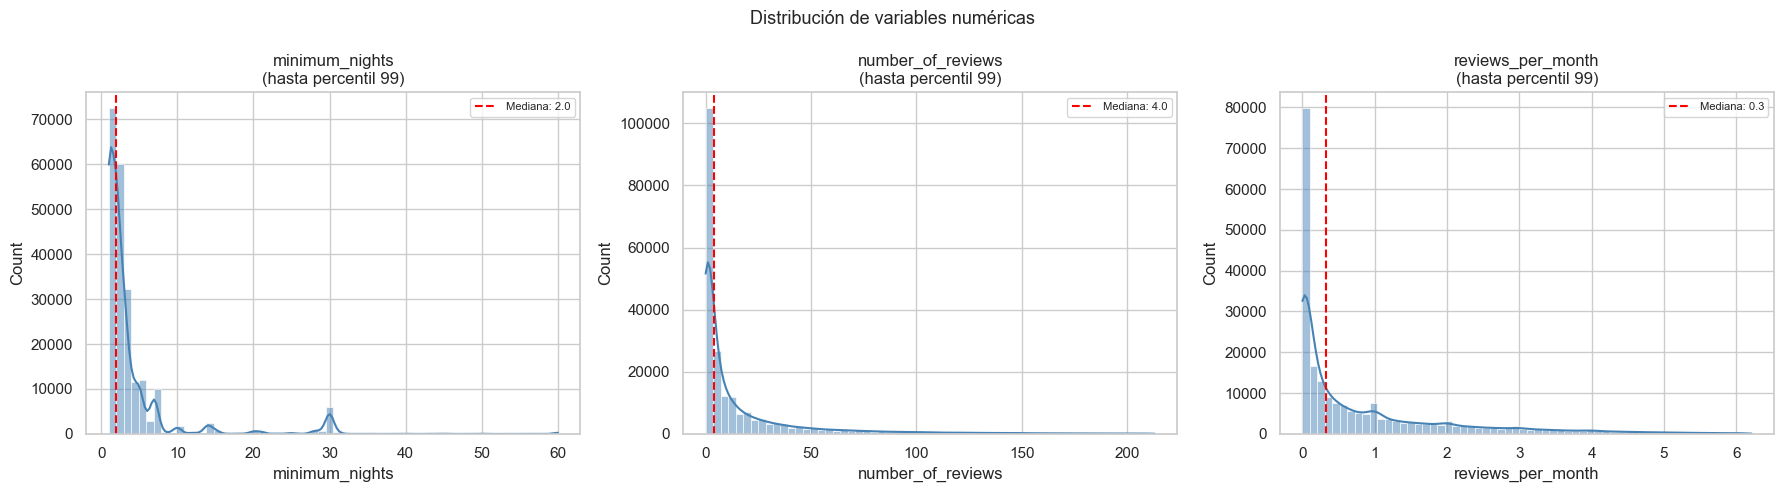


Top 10 valores de minimum_nights (posibles valores fijados manualmente):
minimum_nights
1     72396
2     60082
3     32228
5     11976
4     11537
7     10006
30     6001
6      2962
14     2433
10     1878


In [7]:
VARS_NUM = ['minimum_nights', 'number_of_reviews', 'reviews_per_month']
LIM_PERCENTIL = 0.99  # Mostrar hasta el percentil 99 para no distorsionar

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, var in enumerate(VARS_NUM):
    lim = df[var].quantile(LIM_PERCENTIL)
    datos = df[df[var] <= lim][var]
    sns.histplot(datos, bins=60, ax=axes[i], kde=True, color='steelblue')
    axes[i].set_title(f'{var}\n(hasta percentil {LIM_PERCENTIL*100:.0f})')
    axes[i].axvline(df[var].median(), color='red', ls='--',
                    label=f'Mediana: {df[var].median():.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribución de variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

# Frecuencias de minimum_nights — detectar valores "redondos" sospechosos
print('\nTop 10 valores de minimum_nights (posibles valores fijados manualmente):')
print(df['minimum_nights'].value_counts().head(10).to_string())

### 📊 Interpretación — Variables numéricas

**`minimum_nights`:** Si los valores 1, 2, 7, 30 y 365 son altamente frecuentes, confirma que los hosts fijan manualmente estos valores (1 noche = turismo, 30 = alquiler mensual, 365 = alquiler anual disfrazado de AirBnB). Valores superiores a 365 son datos atípicos.

**`number_of_reviews`:** Distribución tipo Pareto esperada: muchos alojamientos con pocas reviews, pocos con muchas. Un alojamiento sin reviews no implica que sea nuevo — puede llevar tiempo sin alquilarse.

**`reviews_per_month`:** Proxy de la demanda. Valores altos indican alojamientos muy solicitados. Correlacionado negativamente con el precio en mercados competitivos.

---
## 3. Análisis bivariante

### 3.1 Precio vs. room_type por ciudad (boxplot agrupado)

> **[SDD]** Analizar si `room_type` discrimina el precio dentro de cada ciudad. Si las cajas no se solapan, `room_type` es un predictor fuerte.

**Razonamiento:** Esta es la pregunta de negocio más directa: ¿cuánto más caro es alquilar un piso entero vs. una habitación privada? La respuesta varía por ciudad y cultura.

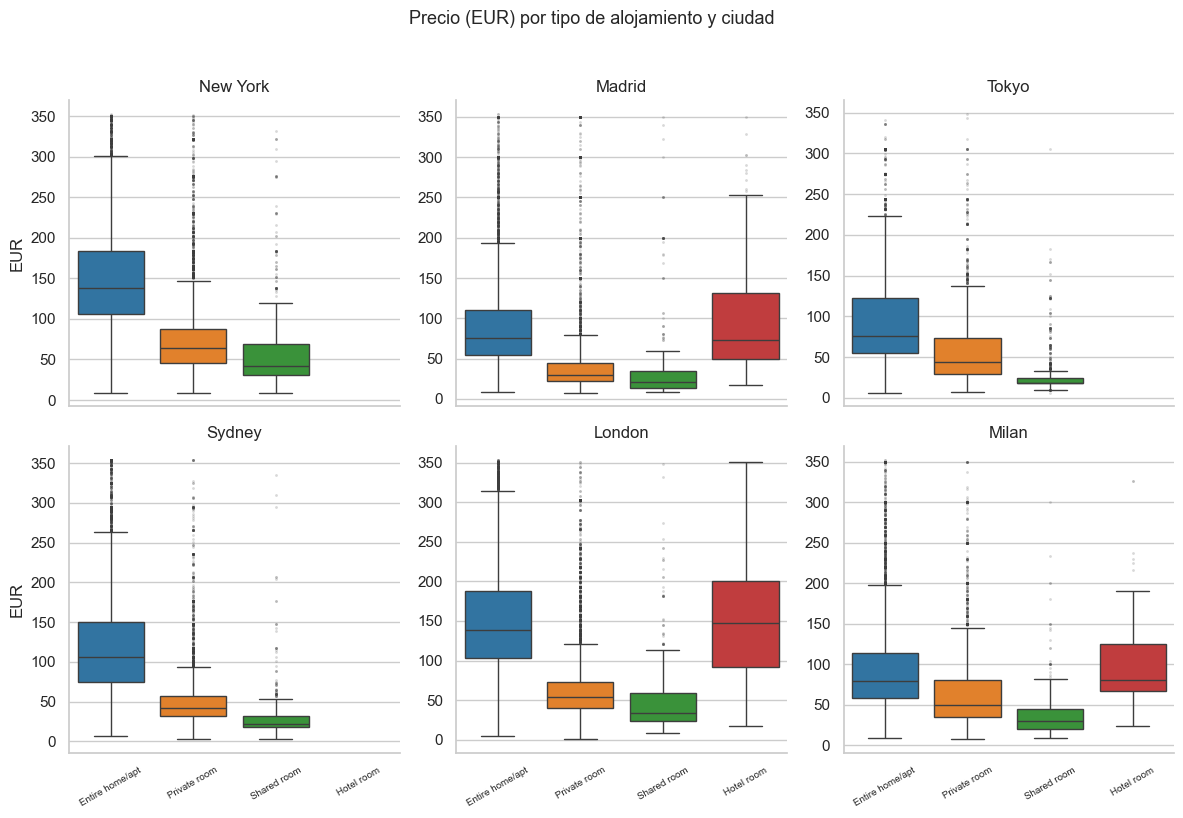


Precio mediano (EUR) por ciudad y room_type:
room_type  Entire home/apt  Hotel room  Private room  Shared room
city                                                             
London               145.0       179.0          54.0         34.0
Madrid                78.0        91.0          32.0         21.0
Milan                 80.0        82.0          50.0         30.0
New York             147.0         NaN          64.0         41.0
Sydney               110.0         NaN          42.0         22.0
Tokyo                 78.0         NaN          45.0         18.0


In [8]:
# SDD: Boxplot agrupado — Rúbrica: Análisis exploratorio detallado
PRECIO_MAX = df['price_eur'].quantile(0.95)
df_bv = df[df['price_eur'] <= PRECIO_MAX]

g = sns.FacetGrid(df_bv, col='city', col_wrap=3, height=4, sharey=False)
g.map_dataframe(sns.boxplot, x='room_type', y='price_eur', palette='tab10',
                flierprops={'markersize': 1, 'alpha': 0.2},
                order=['Entire home/apt', 'Private room', 'Shared room', 'Hotel room'])
g.set_titles(col_template='{col_name}')
g.set_axis_labels('', 'EUR')
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=30, labelsize=7)
g.figure.suptitle('Precio (EUR) por tipo de alojamiento y ciudad', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Tabla de medianas
print('\nPrecio mediano (EUR) por ciudad y room_type:')
pivot = df.groupby(['city','room_type'])['price_eur'].median().unstack().round(0)
print(pivot.to_string())

### 📊 Interpretación — Precio vs. room_type

**Qué buscar:** La separación entre las cajas de `Entire home/apt` y `Private room` mide cuánto premium se paga por privacidad total. En ciudades turísticas (París, Londres, Nueva York) este premium suele ser 2-3×. En ciudades con mercado menos maduro puede ser menor.

**Hotel room** en AirBnB: Si aparece con precios similares o superiores a `Entire home/apt`, indica que AirBnB compite directamente con el sector hotelero en esa ciudad. Si es similar a `Private room`, los hoteles en AirBnB ofrecen precios competitivos.

### 3.2 Precio vs. número de reviews

> **[SDD]** Scatter plot con línea de tendencia. Verificar si hay correlación entre popularidad (reviews) y precio.

**Razonamiento:** La hipótesis intuitiva es que alojamientos más caros tienen menos reviews (menos accesibles). Pero también puede ocurrir lo contrario: alojamientos con muchas reviews tienen buena reputación y pueden cobrar más.

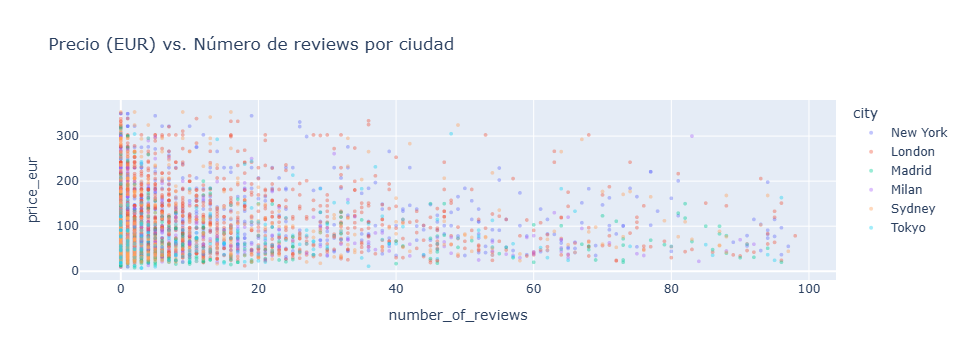

Correlación precio_eur vs. number_of_reviews por ciudad:
  London      : r = -0.067
  Madrid      : r = -0.000
  Milan       : r = -0.041
  New York    : r = -0.048
  Sydney      : r = -0.058
  Tokyo       : r = +0.001


In [9]:
# SDD: Scatter bivariante — sin trendline='ols' para evitar dependencia de statsmodels
df_sc = df[
    (df['price_eur'] <= df['price_eur'].quantile(0.95)) &
    (df['number_of_reviews'] <= df['number_of_reviews'].quantile(0.95))
].sample(min(4000, len(df)), random_state=42)

fig = px.scatter(
    df_sc,
    x='number_of_reviews', y='price_eur',
    color='city', opacity=0.4,
    hover_data=['name', 'room_type', 'neighbourhood'],
    title='Precio (EUR) vs. Número de reviews por ciudad'
)
fig.update_traces(marker=dict(size=4))
fig.show()

# Correlación numérica
print('Correlación precio_eur vs. number_of_reviews por ciudad:')
for ciudad in sorted(df['city'].unique()):
    sub = df[df['city'] == ciudad]
    corr = sub['price_eur'].corr(sub['number_of_reviews'])
    print(f'  {ciudad:12}: r = {corr:+.3f}')

### 📊 Interpretación — Precio vs. reviews

**Cómo leer el coeficiente de correlación r:**
- `r` cercano a 0 → no hay relación lineal entre precio y número de reviews
- `r` negativo → más reviews = precio más bajo (alojamientos asequibles se alquilan más)
- `r` positivo → más reviews = precio más alto (reputación premium)

**Limitación:** La correlación de Pearson solo mide relación **lineal**. Si la relación es curvilínea (por ejemplo, precio alto al principio, luego cae), `r` no lo captará. El scatter plot visual complementa el número.

### 3.3 KDE superpuesto: precio por room_type

> **[SDD]** KDE por categoría permite ver la forma completa de la distribución de cada grupo, no solo sus estadísticos resumidos.

**Razonamiento:** El boxplot resume en 5 números. El KDE muestra si hay bimodalidad (dos subpoblaciones dentro del mismo room_type), asimetría, o solapamiento entre categorías.

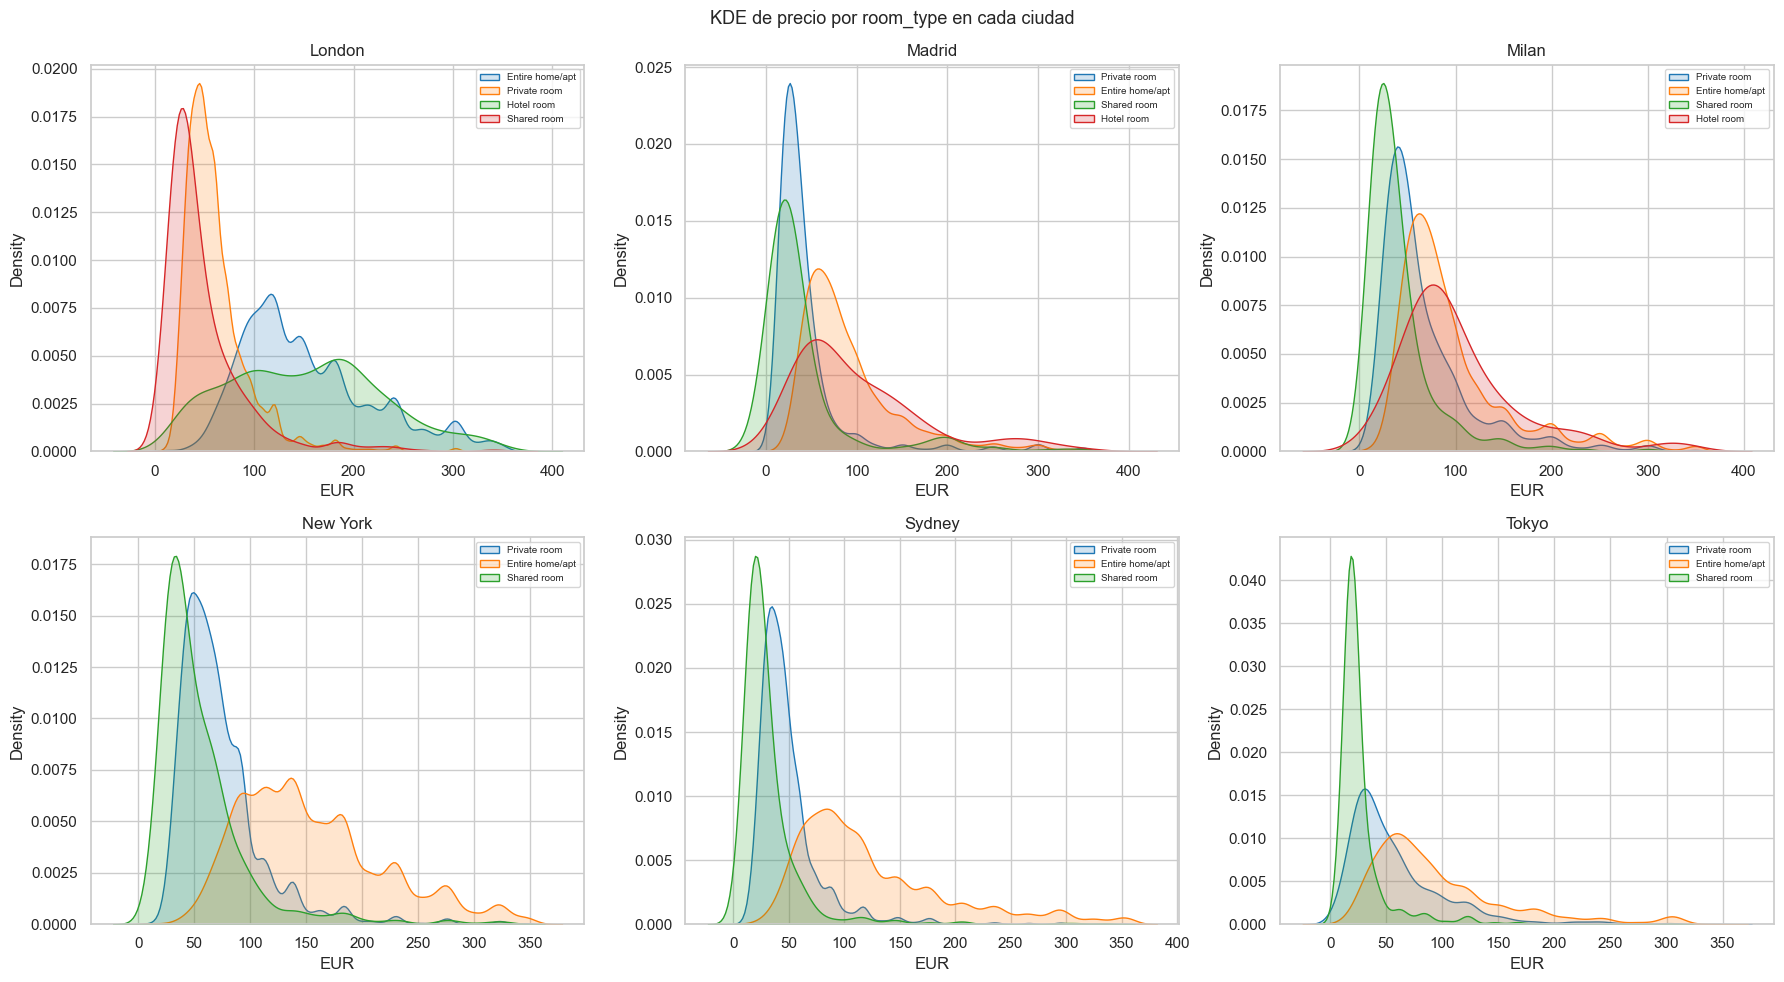

In [10]:
PRECIO_MAX_KDE = df['price_eur'].quantile(0.95)
df_kde = df[df['price_eur'] <= PRECIO_MAX_KDE]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, ciudad in enumerate(sorted(df['city'].unique())):
    sub = df_kde[df_kde['city'] == ciudad]
    for rt in sub['room_type'].unique():
        datos = sub[sub['room_type'] == rt]['price_eur']
        if len(datos) > 10:
            sns.kdeplot(datos, ax=axes[i], label=rt, fill=True, alpha=0.2)
    axes[i].set_title(f'{ciudad}')
    axes[i].set_xlabel('EUR')
    axes[i].legend(fontsize=7)

plt.suptitle('KDE de precio por room_type en cada ciudad', fontsize=13)
plt.tight_layout()
plt.show()

### 📊 Interpretación — KDE por room_type

**Solapamiento entre categorías:** Cuanto más se solapan las curvas de `Entire home/apt` y `Private room`, menos útil es `room_type` como predictor del precio en esa ciudad específica. En ciudades con alto solapamiento, otras variables (barrio, reviews) pueden ser más determinantes.

**Bimodalidad:** Si la curva de una categoría tiene dos picos, sugiere que hay dos subpoblaciones mezcladas (por ejemplo, habitaciones privadas baratas para mochileros y habitaciones privadas de lujo).

---
## 4. Análisis multivariante

### 4.1 Matriz de correlación

> **[SDD]** Calcular y visualizar la matriz de correlación de Pearson para todas las variables numéricas. Identificar multicolinealidad y variables con mayor correlación con el precio.

**Razonamiento:** Si dos variables tienen correlación |r| > 0.8, incluirlas ambas en un modelo de regresión puede causar multicolinealidad — los coeficientes se vuelven inestables y difíciles de interpretar. La matriz permite tomar decisiones de feature selection antes de modelar.

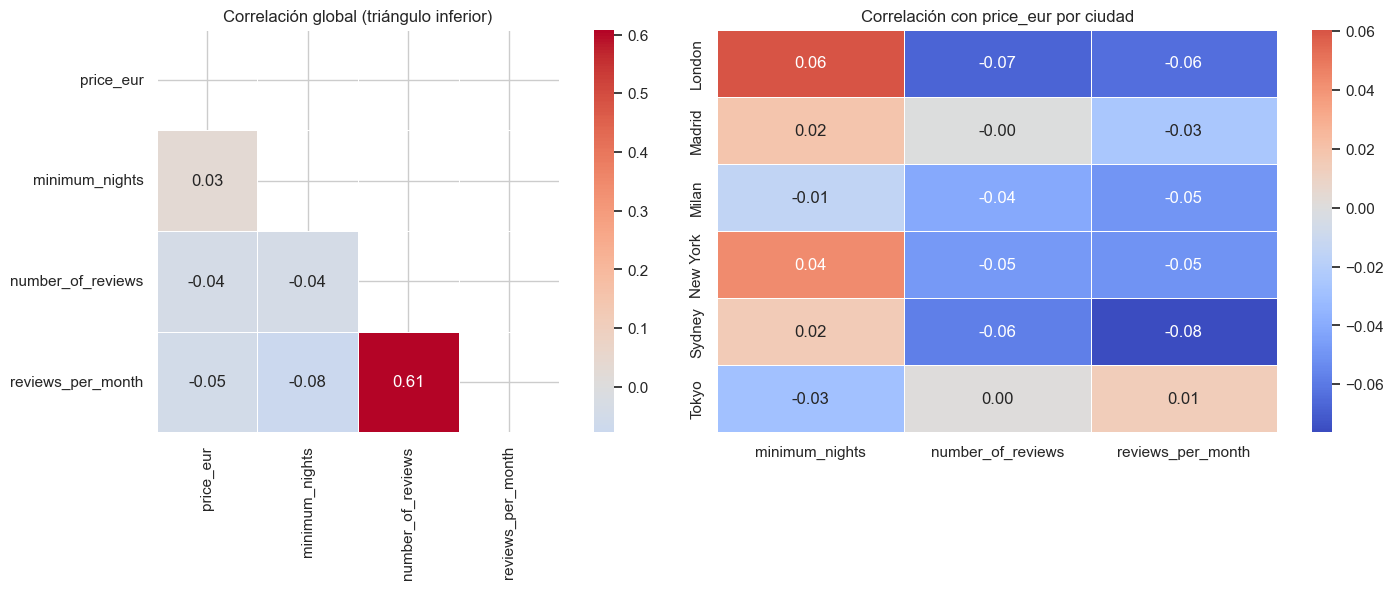

In [11]:
# SDD: Heatmap de correlación — Rúbrica: Análisis exploratorio detallado
COLS_CORR = ['price_eur', 'minimum_nights', 'number_of_reviews', 'reviews_per_month']

corr = df[COLS_CORR].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Global
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=axes[0], mask=mask)
axes[0].set_title('Correlación global (triángulo inferior)')

# Correlación con price_eur por ciudad
corr_ciudad = pd.DataFrame(index=sorted(df['city'].unique()),
                           columns=[c for c in COLS_CORR if c != 'price_eur'])
for ciudad in corr_ciudad.index:
    sub = df[df['city'] == ciudad][COLS_CORR]
    for col in corr_ciudad.columns:
        corr_ciudad.loc[ciudad, col] = sub['price_eur'].corr(sub[col])

corr_ciudad = corr_ciudad.astype(float)
sns.heatmap(corr_ciudad, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Correlación con price_eur por ciudad')

plt.tight_layout()
plt.show()

### 📊 Interpretación — Matriz de correlación

**Qué buscar en el heatmap global:**
- `reviews_per_month` y `number_of_reviews` suelen tener correlación alta — son redundantes si se usan juntas
- La correlación de `minimum_nights` con `price_eur` puede variar: en algunos mercados los alquileres de más noches tienen precio por noche menor (descuento)

**Qué buscar en el heatmap por ciudad:**
- Si la correlación de una variable con el precio es consistente en todas las ciudades → variable robusta
- Si varía mucho entre ciudades → la relación depende del mercado local y debería modelarse por separado

### 4.2 Pairplot

> **[SDD]** Visualización de todas las relaciones bivariantes simultáneamente, coloreadas por ciudad. Permite ver de un vistazo qué combinaciones de variables separan mejor los grupos.

**Razonamiento:** El pairplot es la "foto de satélite" del dataset. Identifica relaciones no lineales que el heatmap no captura y da pistas sobre qué variables combinar para un modelo.

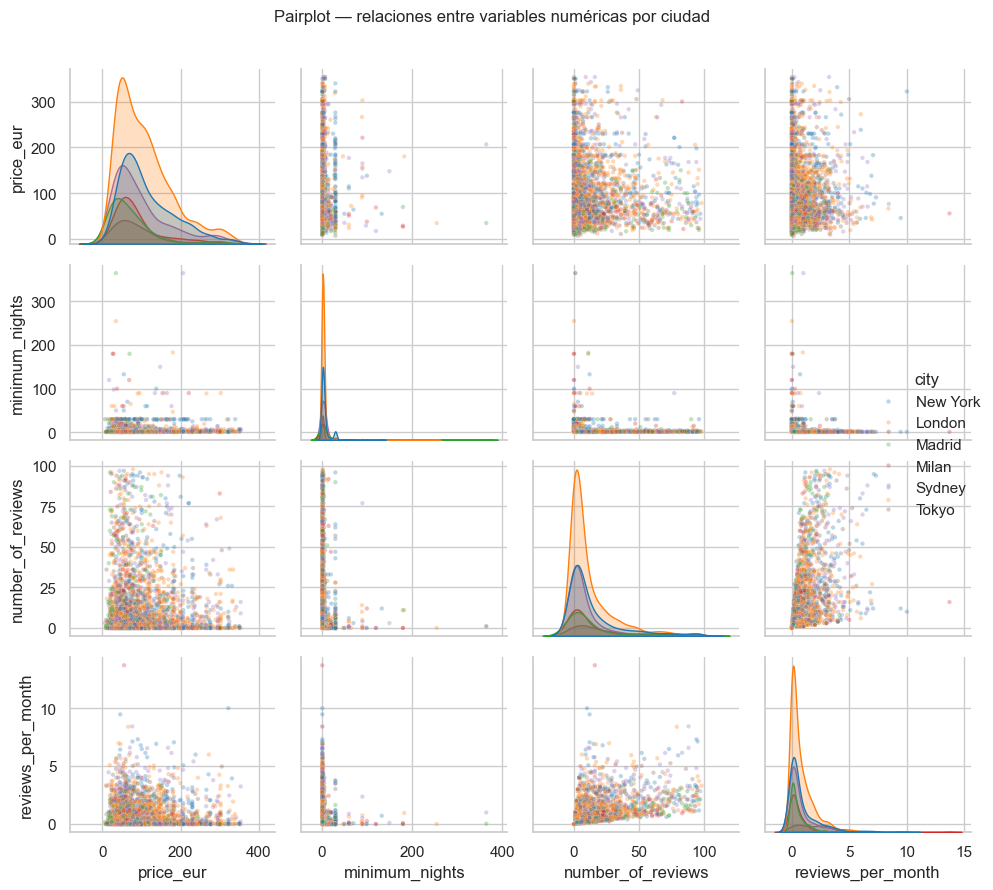

In [12]:
# SDD: Pairplot — muestra aleatoria para no saturar memoria
df_pp = df[
    (df['price_eur'] <= df['price_eur'].quantile(0.95)) &
    (df['number_of_reviews'] <= df['number_of_reviews'].quantile(0.95))
].sample(min(3000, len(df)), random_state=42)

g = sns.pairplot(
    df_pp[['price_eur', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'city']],
    hue='city',
    plot_kws={'alpha': 0.3, 's': 10},
    diag_kind='kde',
    height=2.2
)
g.figure.suptitle('Pairplot — relaciones entre variables numéricas por ciudad', y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Patrones geográficos

> **[SDD]** Visualizar la distribución geográfica de los alojamientos y su precio. Los datos ya están validados geográficamente por el notebook de homogenización.

**Razonamiento:** La localización es uno de los factores más influyentes en el precio de cualquier alojamiento. Un mapa interactivo permite identificar zonas de alta concentración y zonas premium.

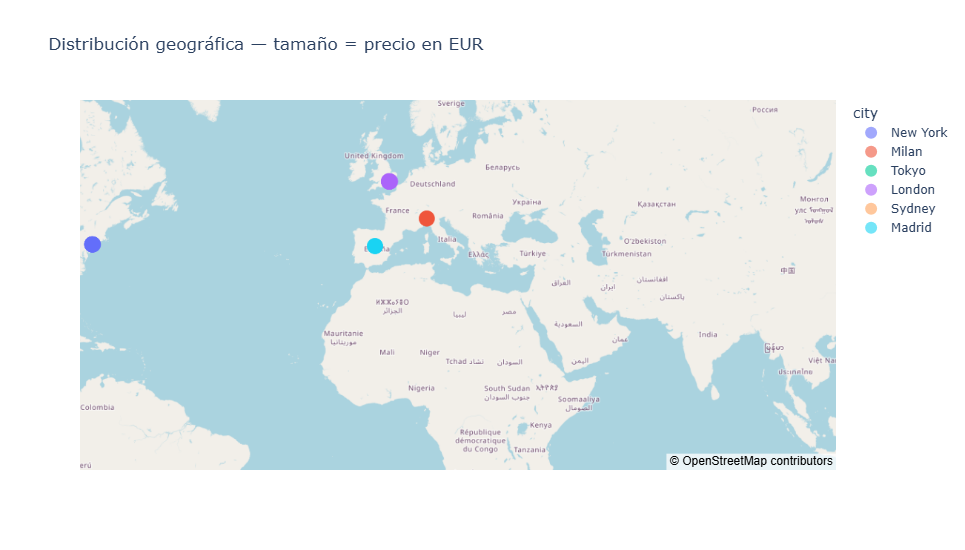

In [13]:
# SDD: Mapa geográfico interactivo — Rúbrica: Visualización de datos (plotly)
df_mapa = df[
    df['price_eur'] <= df['price_eur'].quantile(0.95)
].sample(min(6000, len(df)), random_state=42)

fig = px.scatter_mapbox(
    df_mapa,
    lat='latitude', lon='longitude',
    color='city',
    size='price_eur',
    size_max=12,
    hover_name='name',
    hover_data={'price_eur': True, 'room_type': True,
                'neighbourhood': True, 'number_of_reviews': True},
    mapbox_style='open-street-map',
    zoom=1.5,
    opacity=0.6,
    title='Distribución geográfica — tamaño = precio en EUR'
)
fig.update_layout(height=550)
fig.show()

In [14]:
# Precio mediano por barrio — top 10 más caros por ciudad
print('=== TOP 5 BARRIOS MÁS CAROS POR CIUDAD (precio mediano EUR) ===')
print()
for ciudad in sorted(df['city'].unique()):
    sub = df[df['city'] == ciudad]
    top = (sub.groupby('neighbourhood')['price_eur']
             .agg(['median','count'])
             .query('count >= 10')
             .sort_values('median', ascending=False)
             .head(5))
    print(f'--- {ciudad} ---')
    print(top.rename(columns={'median':'EUR mediano','count':'n aloj.'}).to_string())
    print()

=== TOP 5 BARRIOS MÁS CAROS POR CIUDAD (precio mediano EUR) ===

--- London ---
                        EUR mediano  n aloj.
neighbourhood                               
City of London               181.50      465
Kensington and Chelsea       181.50     6018
Westminster                  169.40     9586
Camden                       121.00     5971
Hammersmith and Fulham       114.95     4210

--- Madrid ---
               EUR mediano  n aloj.
neighbourhood                      
Hellín               300.0       31
Rosas                275.0       80
Canillejas           200.0       77
Recoletos            110.5      272
Castellana            98.0      198

--- Milan ---
                      EUR mediano  n aloj.
neighbourhood                             
TRE TORRI                   125.0       24
DUOMO                       120.0     1003
BRERA                       120.0      713
MAGENTA - S. VITTORE        100.0      415
GUASTALLA                    98.5      348

--- New York ---
   

### 📊 Interpretación — Patrones geográficos

**Qué buscar en el mapa:** Los puntos más grandes (precios más altos) deberían concentrarse en zonas céntricas o turísticas. Si hay puntos grandes en zonas periféricas, puede indicar alojamientos atípicos (villas, casas rurales) o errores de coordenadas residuales.

**Barrios más caros:** Confirman que la geografía explica una parte importante del precio. Un modelo que incluya `neighbourhood` como variable debería mejorar significativamente respecto a uno que solo use `room_type` y `city`.

---
## 6. Conclusiones y hallazgos

> **[SDD]** Documentar los hallazgos principales del EDA. Cada conclusión debe estar respaldada por la evidencia visual o numérica de las secciones anteriores. Las hipótesis pendientes de validación estadística se marcan explícitamente.

In [15]:
# SDD: Resumen numérico de hallazgos para documentar
print('=== RESUMEN DEL EDA ===')
print(f'Total alojamientos analizados: {len(df):,}')
print()
print('Precio mediano por ciudad (EUR):')
print(df.groupby('city')['price_eur'].median().sort_values(ascending=False).round(0).to_string())
print()
print('Tipo de alojamiento más frecuente por ciudad:')
print(df.groupby('city')['room_type'].agg(lambda x: x.value_counts().index[0]).to_string())
print()
print('Mediana de minimum_nights por ciudad:')
print(df.groupby('city')['minimum_nights'].median().sort_values().to_string())
print()
print('Ciudad con más reviews por alojamiento (media):')
print(df.groupby('city')['number_of_reviews'].mean().round(1).sort_values(ascending=False).to_string())

=== RESUMEN DEL EDA ===
Total alojamientos analizados: 219,981

Precio mediano por ciudad (EUR):
city
London      102.0
New York     98.0
Sydney       80.0
Milan        74.0
Tokyo        61.0
Madrid       58.0

Tipo de alojamiento más frecuente por ciudad:
city
London      Entire home/apt
Madrid      Entire home/apt
Milan       Entire home/apt
New York    Entire home/apt
Sydney      Entire home/apt
Tokyo       Entire home/apt

Mediana de minimum_nights por ciudad:
city
Tokyo       1.0
London      2.0
Milan       2.0
Madrid      2.0
Sydney      2.0
New York    3.0

Ciudad con más reviews por alojamiento (media):
city
Madrid      31.9
Tokyo       26.0
Milan       23.7
New York    23.3
London      17.5
Sydney      12.2


### Hallazgos principales

> Completar con los resultados reales tras ejecutar el notebook.

- [ ] **Ciudad más cara en EUR:** _____ (mediana: ___€)
- [ ] **Ciudad más barata en EUR:** _____ (mediana: ___€)
- [ ] **Tipo de alojamiento dominante globalmente:** _____  (___%)
- [ ] **Variable más correlacionada con el precio:** _____  (r = ___)
- [ ] **Ciudad con mayor dispersión de precios:** _____ (IQR = ___€)
- [ ] **Barrio más caro identificado:** _____ en _____

### Hipótesis para validar con tests estadísticos

1. **H₁:** El precio mediano difiere significativamente entre ciudades → Test ANOVA
2. **H₂:** Los alojamientos con `Entire home/apt` tienen precio significativamente mayor que `Private room` → Test t
3. **H₃:** Existe correlación negativa entre `number_of_reviews` y `price_eur` → Correlación de Spearman
4. **H₄:** El barrio explica más varianza del precio que el `room_type` → ANOVA / Regresión

### Señales de riesgo para el modelado

| Señal detectada | Riesgo | Acción recomendada |
|---|---|---|
| Distribución de precio sesgada a la derecha | Modelos que asumen normalidad se degradan | Transformación log(price) |
| Alta correlación reviews/month ↔ n_reviews | Multicolinealidad | Usar solo una de las dos |
| Clases de room_type desbalanceadas | Modelo predice solo la clase mayoritaria | class_weight o submuestreo |
| Precios en moneda local sin normalizar | Comparaciones entre ciudades inválidas | Usar price_eur |

### Próximos pasos

- [ ] Dashboard en Looker Studio con filtros por ciudad y room_type
- [ ] Tests estadísticos para las hipótesis listadas
- [ ] Modelo de clustering K-Means para segmentar tipos de alojamiento
- [ ] Modelo de regresión para predecir precio a partir de características